# gprMax B-scan input-file generator
Common-Offset B-scan: a single source and single receiver step together across the domain.
- Uses native `#src_steps` / `#rx_steps` gprMax commands — no Python loop needed in the `.in` file.
- Generates two `.in` files: **Baseline** (Model A) and **Timelapse** (Model B, blocks shifted).
- Snapshots are captured **only** when the pair is at the domain centre (saves disk space).
- The **Total Traces** printed by Cell 2 is the `-n` argument for gprMax: `python -m gprMax baseline.in -n <N>`.

In [1]:
import numpy as np
from fractions import Fraction

# ── Simulation frequency ──────────────────────────────────────────────────────
f_central = 1.5e9          # [Hz]  centre frequency
c         = 3e8            # [m/s] speed of light in vacuum

# ── Material permittivities & conductivities ──────────────────────────────────
eps_ice,   sigma_ice   = 3.15, 1e-6
eps_air,   sigma_air   = 1.0,  0.0
eps_water, sigma_water = 80.0, 0.01

# ── Block geometry ────────────────────────────────────────────────────────────
block_width_fraction = Fraction(1, 5)    # block width as fraction of lambda_ice
fracture_aperture    = None              # [m]  None -> auto-set to lambda_min / 5

# ── Domain geometry ───────────────────────────────────────────────────────────
domain_width   = 4.0   # [m]
air_thickness  = 0.1   # [m] air layer above ice surface
fracture_depth = 0.6   # [m] depth from ice surface to top of fracture
depth_below    = 0.1   # [m] ice below the fracture

# ── B-scan antenna parameters ─────────────────────────────────────────────────
offset        = 0.02   # [m]  source-receiver separation (near zero-offset, ~2 cm)
trace_spacing = None   # [m]  None -> auto lambda_ice / 10; or e.g. 0.02
scan_margin   = None   # [m]  None -> auto 2*dx from each edge

# ── Timelapse shift ───────────────────────────────────────────────────────────
shift_fraction = 0.25   # Model B blocks shifted by (shift_fraction * lambda_ice)

# ── Snapshots ─────────────────────────────────────────────────────────────────
enable_snapshots = True    # False -> no #snapshot lines (faster runs)
snap_dl_factor   = 10      # snapshot resolution = snap_dl_factor * dx
snap_interval    = 0.5e-9  # [s] time between consecutive snapshots

# ── Derived wavelengths & required grid spacing ───────────────────────────────
c_ice        = c / np.sqrt(eps_ice)
c_water      = c / np.sqrt(eps_water)
lambda_ice   = c_ice   / f_central
lambda_water = c_water / f_central
lambda_min   = min(lambda_ice, lambda_water)

dx = lambda_min / 30   # >= 30 cells per shortest wavelength

print(f'lambda_ice   = {lambda_ice*1e2:.3f} cm')
print(f'lambda_water = {lambda_water*1e3:.3f} mm')
print(f'dx           = {dx*1e3:.4f} mm')

lambda_ice   = 11.269 cm
lambda_water = 22.361 mm
dx           = 0.7454 mm


In [2]:
# ── Fracture aperture ─────────────────────────────────────────────────────────
if fracture_aperture is None:
    fracture_aperture = lambda_min / 5

# ── Block sizing & timelapse shift ────────────────────────────────────────────
block_width      = block_width_fraction * lambda_ice
time_lapse_shift = shift_fraction * lambda_ice

# ── Domain snapped to grid ────────────────────────────────────────────────────
domain_height = air_thickness + fracture_depth + fracture_aperture + depth_below
domain_width  = np.ceil(domain_width  / dx) * dx
domain_height = np.ceil(domain_height / dx) * dx

# ── Time window (5 periods + 3x two-way travel to fracture) ──────────────────
TW = (5 / f_central) + 3 * (fracture_depth + fracture_aperture) / c_ice

# ── gprMax y-coordinates (origin at bottom-left corner) ──────────────────────
y_surface  = domain_height - air_thickness
y_frac_top = domain_height - (air_thickness + fracture_depth)
y_frac_bot = y_frac_top - fracture_aperture
y_frac_min = min(y_frac_top, y_frac_bot)
y_frac_max = max(y_frac_top, y_frac_bot)

# ── Block count (must be even for Air/Water alternation) ─────────────────────
n_blocks = int(np.round(domain_width / block_width))
if n_blocks < 1:      n_blocks = 1
if n_blocks % 2 != 0: n_blocks += 1
block_width_actual = domain_width / n_blocks

# ── Trace spacing snapped to grid ────────────────────────────────────────────
if trace_spacing is None:
    trace_spacing = lambda_ice / 10
trace_spacing = np.round(trace_spacing / dx) * dx

# ── Scan margin ───────────────────────────────────────────────────────────────
if scan_margin is None:
    scan_margin = 2 * dx

# ── Starting positions (Tx left-most, Rx = Tx + offset) ──────────────────────
tx_start_x = scan_margin
rx_start_x = tx_start_x + offset

# ── Number of traces: Rx scans until it reaches the right-edge margin ────────
scan_length = domain_width - rx_start_x - scan_margin
n_traces    = int(np.floor(scan_length / trace_spacing)) + 1
tx_end_x    = tx_start_x + (n_traces - 1) * trace_spacing
rx_end_x    = rx_start_x + (n_traces - 1) * trace_spacing

# ── Center trace (1-indexed) for snapshot trigger ────────────────────────────
center_x     = domain_width / 2
center_trace = int(np.round((center_x - tx_start_x) / trace_spacing)) + 1
center_trace = max(1, min(center_trace, n_traces))

# ── Human-readable block label ────────────────────────────────────────────────
fr = Fraction(block_width_actual / lambda_ice).limit_denominator(32)
block_label = f'{fr.numerator}/{fr.denominator} λ_ice'

print(f'Domain:            {domain_width:.4f} m x {domain_height:.4f} m')
print(f'Grid cells:        {domain_width/dx:.0f} x {domain_height/dx:.0f}')
print(f'Fracture aperture: {fracture_aperture*1e3:.3f} mm')
print(f'Block width:       {block_width_actual*1e3:.3f} mm  ({block_label})')
print(f'N blocks:          {n_blocks}')
print(f'Timelapse shift:   {time_lapse_shift*1e3:.3f} mm  ({shift_fraction} λ_ice)')
print(f'Time window:       {TW*1e9:.3f} ns')
print()
print(f'-- B-scan geometry --')
print(f'Offset (Tx-Rx):    {offset*1e2:.1f} cm')
print(f'Trace spacing:     {trace_spacing*1e3:.3f} mm  (λ_ice/10 = {lambda_ice/10*1e3:.3f} mm)')
print(f'Tx start -> end:   {tx_start_x:.4f} m -> {tx_end_x:.4f} m')
print(f'Rx start -> end:   {rx_start_x:.4f} m -> {rx_end_x:.4f} m')
print()
print(f'★  Total traces (use -n flag):  {n_traces}')
print(f'   Snapshot at trace:          {center_trace}  (Tx at x = {tx_start_x + (center_trace - 1)*trace_spacing:.3f} m)')

Domain:            4.0003 m x 0.8050 m
Grid cells:        5367 x 1080
Fracture aperture: 4.472 mm
Block width:       22.474 mm  (1/5 λ_ice)
N blocks:          178
Timelapse shift:   28.172 mm  (0.25 λ_ice)
Time window:       14.062 ns

-- B-scan geometry --
Offset (Tx-Rx):    2.0 cm
Trace spacing:     11.180 mm  (λ_ice/10 = 11.269 mm)
Tx start -> end:   0.0015 m -> 3.9705 m
Rx start -> end:   0.0215 m -> 3.9905 m

★  Total traces (use -n flag):  356
   Snapshot at trace:          180  (Tx at x = 2.003 m)


In [3]:
import os

output_dir  = os.path.dirname(os.path.abspath('__file__'))
file_prefix = ''   # e.g. 'run1' -> run1_baseline.in / run1_timelapse.in
                   # leave '' for default names: baseline.in / timelapse.in


def _fname(prefix, suffix):
    return f'{prefix}_{suffix}.in' if prefix else f'{suffix}.in'


def build_in_file(block_shift, title, snap_name='snap'):
    lines = [
        f'#title: {title}',
        f'#domain: {domain_width} {domain_height} {dx}',
        f'#dx_dy_dz: {dx} {dx} {dx}',
        f'#time_window: {TW}',
        f'#material: {eps_ice} {sigma_ice} 1 0 ice',
        f'#material: {eps_air} {sigma_air} 1 0 fracture_air',
        f'#material: {eps_water} {sigma_water} 1 0 fracture_water',
        f'#waveform: ricker 1 {f_central} my_ricker',
        # B-scan starting positions
        f'#hertzian_dipole: z {tx_start_x} {y_surface} 0 my_ricker',
        f'#rx: {rx_start_x} {y_surface} 0',
        # Native step commands: both antennas advance identically each trace
        f'#src_steps: {trace_spacing} 0 0',
        f'#rx_steps: {trace_spacing} 0 0',
        # Static geometry
        f'#box: 0 {y_surface} 0 {domain_width} {domain_height} {dx} free_space',
        f'#box: 0 0 0 {domain_width} {y_surface} {dx} ice',
    ]

    for i in range(n_blocks):
        x0 = i * block_width_actual + block_shift
        x1 = x0 + block_width_actual
        x0 = min(max(0.0, x0), domain_width)
        x1 = min(max(0.0, x1), domain_width)
        if x0 >= x1:
            continue
        mat = 'fracture_air' if i % 2 == 0 else 'fracture_water'
        lines.append(f'#box: {x0} {y_frac_min} 0 {x1} {y_frac_max} {dx} {mat}')

    # Conditional snapshots: only fire on the centre trace to save memory
    if enable_snapshots:
        snap_dl = snap_dl_factor * dx
        n_snaps = max(1, int(TW / snap_interval))
        py_lines = [
            '#python:',
            'from gprMax.input_cmd_funcs import *',
            f'if current_model_run == {center_trace}:',
        ]
        for k in range(1, n_snaps + 1):
            t = k * snap_interval
            cmd = (f'#snapshot: 0 0 0 {domain_width:.6g} {domain_height:.6g} {dx:.6g}'
                   f' {snap_dl:.6g} {snap_dl:.6g} {dx:.6g} {t:.6g} {snap_name}_{k}')
            py_lines.append(f'    print({repr(cmd)})')
        py_lines.append('#end_python:')
        lines.extend(py_lines)

    return '\n'.join(lines)


tag = f' [{file_prefix}]' if file_prefix else ''
baseline_path  = os.path.join(output_dir, _fname(file_prefix, 'baseline'))
timelapse_path = os.path.join(output_dir, _fname(file_prefix, 'timelapse'))

with open(baseline_path, 'w') as f:
    stem_b = _fname(file_prefix, 'baseline')[:-3]
    f.write(build_in_file(0.0,              f'Model A -- Baseline{tag}',  snap_name=stem_b))
with open(timelapse_path, 'w') as f:
    stem_t = _fname(file_prefix, 'timelapse')[:-3]
    f.write(build_in_file(time_lapse_shift, f'Model B -- Timelapse{tag}', snap_name=stem_t))

print(f'Wrote: {baseline_path}')
print(f'Wrote: {timelapse_path}')
print()
print(f'Run commands:')
print(f'  python -m gprMax baseline.in  -n {n_traces}')
print(f'  python -m gprMax timelapse.in -n {n_traces}')

Wrote: c:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\baseline.in
Wrote: c:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\timelapse.in

Run commands:
  python -m gprMax baseline.in  -n 356
  python -m gprMax timelapse.in -n 356


C:\Users\Administrator\AppData\Local\Temp\ipykernel_26680\3640447596.py:59: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26680\3640447596.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


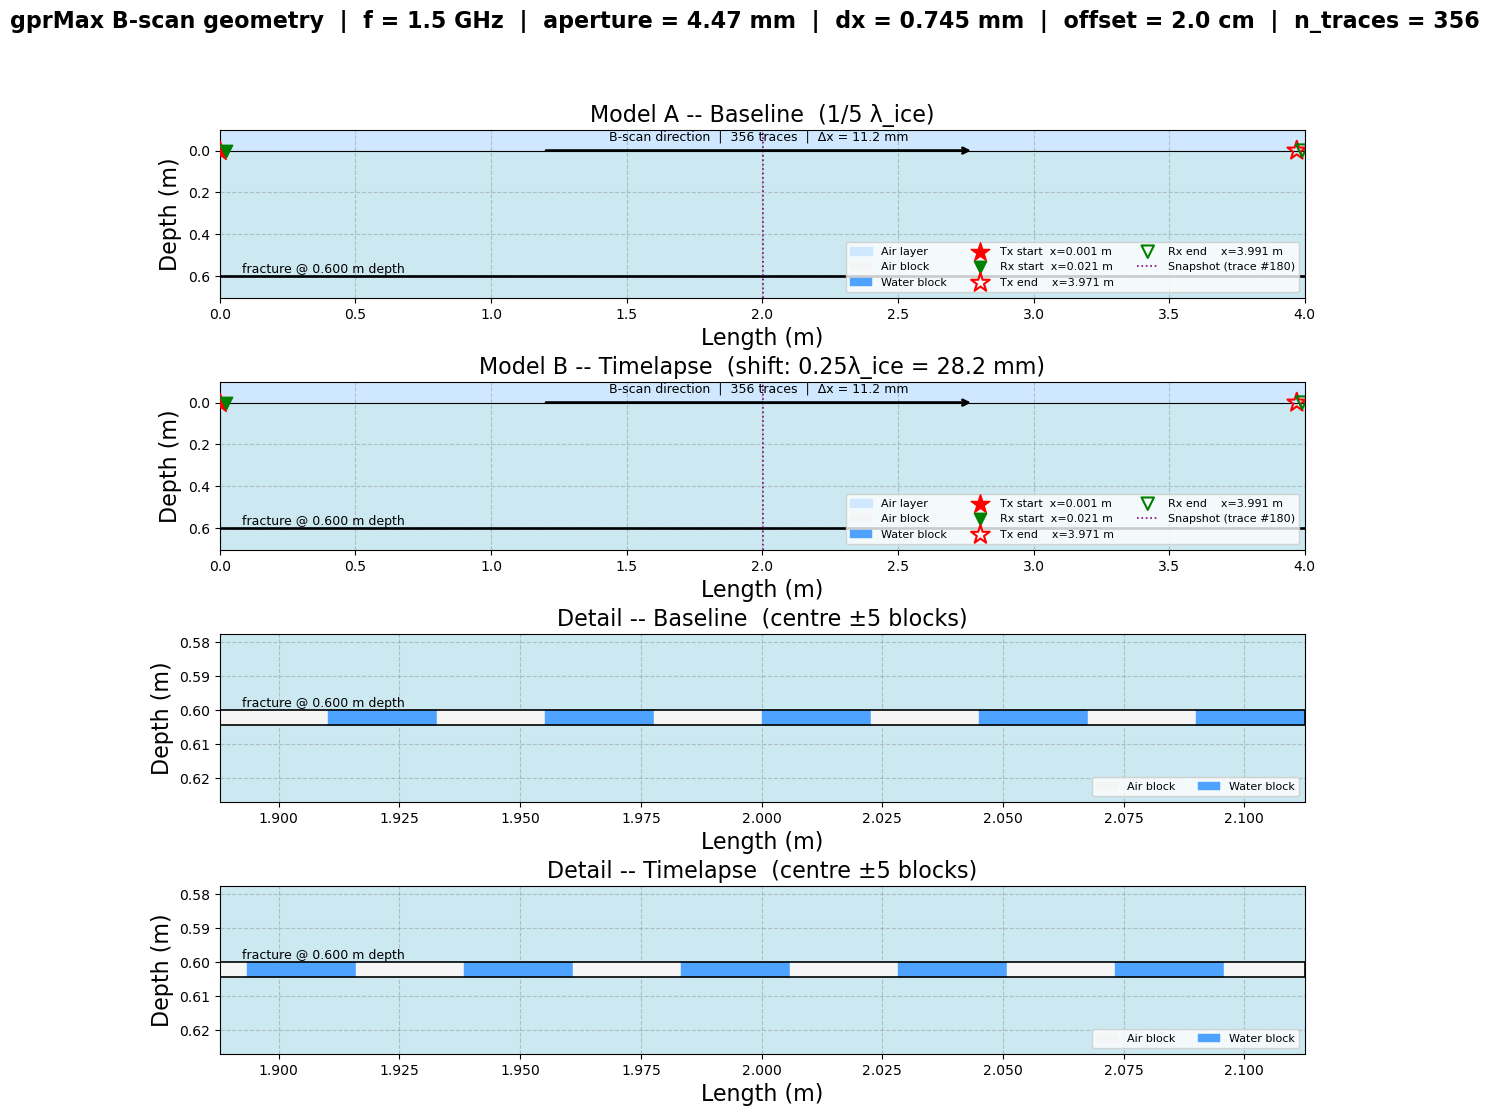

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

# ── Style constants (matching inputfile_generator / notebook_experiment_9) ───
ICE_COLOR      = '#cce8f0'
AIR_COLOR      = '#cfe8ff'
FRAC_AIR_COLOR = '#f5f5f5'
FRAC_WAT_COLOR = '#4da3ff'
LABEL_SIZE     = 16
TITLE_SIZE     = 16

depth_total = fracture_depth + fracture_aperture + depth_below

fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(4, 1, figure=fig, hspace=0.5)
ax_A     = fig.add_subplot(gs[0])
ax_B     = fig.add_subplot(gs[1], sharex=ax_A)
ax_A_det = fig.add_subplot(gs[2])
ax_B_det = fig.add_subplot(gs[3], sharex=ax_A_det)


def draw_model(ax, block_shift, title, zoom=None):
    """
    Plot in depth coordinates (0 = ice surface, increases downward).
    zoom=None      -> full domain with B-scan antenna markers.
    zoom=(xc, hw)  -> fracture detail around xc +/- hw.
    """
    if zoom is None:
        x_lo, x_hi   = 0.0, domain_width
        y_bot, y_top  = depth_total, -air_thickness
        show_antennas = True
    else:
        x_c, hw = zoom
        x_lo, x_hi   = max(0.0, x_c - hw), min(domain_width, x_c + hw)
        margin        = max(5 * fracture_aperture, 0.01)
        y_bot         = fracture_depth + fracture_aperture + margin
        y_top         = fracture_depth - margin
        show_antennas = False

    ax.set_facecolor(ICE_COLOR)

    if zoom is None:
        ax.add_patch(patches.Rectangle(
            (x_lo, -air_thickness), x_hi - x_lo, air_thickness,
            color=AIR_COLOR, zorder=1, label='Air layer'))
        ax.axhline(0, color='black', linewidth=0.8, zorder=4)

    # Fracture blocks — one Rectangle per #box in the .in file
    for i in range(n_blocks):
        bx0 = i * block_width_actual + block_shift
        bx1 = bx0 + block_width_actual
        bx0 = min(max(0.0, bx0), domain_width)
        bx1 = min(max(0.0, bx1), domain_width)
        if bx0 >= bx1:
            continue
        color = FRAC_AIR_COLOR if i % 2 == 0 else FRAC_WAT_COLOR
        lbl   = 'Air block' if i == 0 else ('Water block' if i == 1 else None)
        ax.add_patch(patches.Rectangle(
            (bx0, fracture_depth), bx1 - bx0, fracture_aperture,
            color=color, zorder=2, label=lbl, linewidth=0.3, edgecolor='grey'))

    ax.add_patch(patches.Rectangle(
        (x_lo, fracture_depth), x_hi - x_lo, fracture_aperture,
        fill=False, edgecolor='black', linewidth=1.2, zorder=3))

    if show_antennas:
        y_ant = 0.0   # ice surface in depth coordinates

        # Filled markers = start position; hollow markers = end position
        ax.scatter([tx_start_x], [y_ant], marker='*', s=200, color='red',
                   zorder=6, label=f'Tx start  x={tx_start_x:.3f} m')
        ax.scatter([rx_start_x], [y_ant], marker='v', s=80, color='green',
                   zorder=6, label=f'Rx start  x={rx_start_x:.3f} m')
        ax.scatter([tx_end_x], [y_ant], marker='*', s=200,
                   facecolors='none', edgecolors='red', linewidths=1.5,
                   zorder=6, label=f'Tx end    x={tx_end_x:.3f} m')
        ax.scatter([rx_end_x], [y_ant], marker='v', s=80,
                   facecolors='none', edgecolors='green', linewidths=1.5,
                   zorder=6, label=f'Rx end    x={rx_end_x:.3f} m')

        # Direction arrow across the scan midpoint
        mid_x     = (tx_start_x + tx_end_x) / 2
        arrow_len = (tx_end_x - tx_start_x) * 0.4
        ax.annotate(
            '', xy=(mid_x + arrow_len / 2, y_ant),
            xytext=(mid_x - arrow_len / 2, y_ant),
            arrowprops=dict(arrowstyle='->', color='black', lw=2.0), zorder=7)
        ax.text(mid_x, y_ant - air_thickness * 0.35,
                f'B-scan direction  |  {n_traces} traces  |  Δx = {trace_spacing*1e3:.1f} mm',
                ha='center', va='bottom', fontsize=9, color='black', zorder=7)

        # Snapshot trace marker (purple dashed vertical line)
        snap_tx_x = tx_start_x + (center_trace - 1) * trace_spacing
        ax.axvline(snap_tx_x, color='purple', linestyle=':', linewidth=1.2,
                   zorder=5, label=f'Snapshot (trace #{center_trace})')

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_bot, y_top)
    ax.set_xlabel('Length (m)', fontsize=LABEL_SIZE)
    ax.set_ylabel('Depth (m)',  fontsize=LABEL_SIZE)
    ax.set_title(title, fontsize=TITLE_SIZE)
    ax.grid(True, linestyle='--', alpha=0.4, color='grey')
    ax.legend(loc='lower right', fontsize=8, ncol=3)
    ax.annotate(
        f'fracture @ {fracture_depth:.3f} m depth',
        xy=(x_lo + 0.02 * (x_hi - x_lo), fracture_depth),
        fontsize=9, color='black', va='bottom')


# ── Full-domain views ─────────────────────────────────────────────────────────
draw_model(ax_A, 0.0,
           f'Model A -- Baseline  ({block_label})')
draw_model(ax_B, time_lapse_shift,
           f'Model B -- Timelaps e  (shift: {shift_fraction}λ_ice = {time_lapse_shift*1e3:.1f} mm)')

# ── Fracture detail views (+/- 5 blocks around domain centre) ─────────────────
zoom_hw = 5 * block_width_actual
draw_model(ax_A_det, 0.0,
           'Detail -- Baseline  (centre ±5 blocks)',
           zoom=(domain_width / 2, zoom_hw))
draw_model(ax_B_det, time_lapse_shift,
           'Detail -- Timelapse  (centre ±5 blocks)',
           zoom=(domain_width / 2, zoom_hw))

fig.suptitle(
    f'gprMax B-scan geometry  |  f = {f_central/1e9:.1f} GHz  |  '
    f'aperture = {fracture_aperture*1e3:.2f} mm  |  dx = {dx*1e3:.3f} mm  |  '
    f'offset = {offset*1e2:.1f} cm  |  n_traces = {n_traces}',
    fontsize=TITLE_SIZE, weight='bold')
plt.tight_layout()
plt.show()